   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


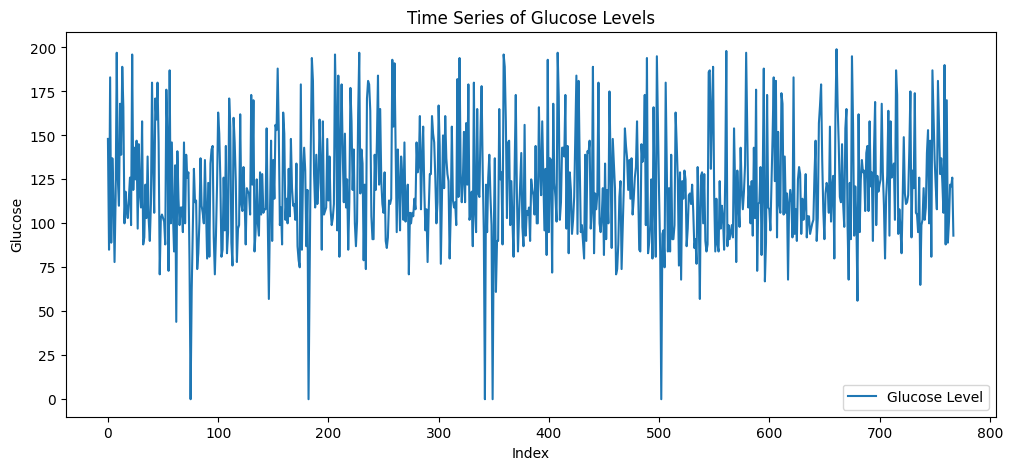

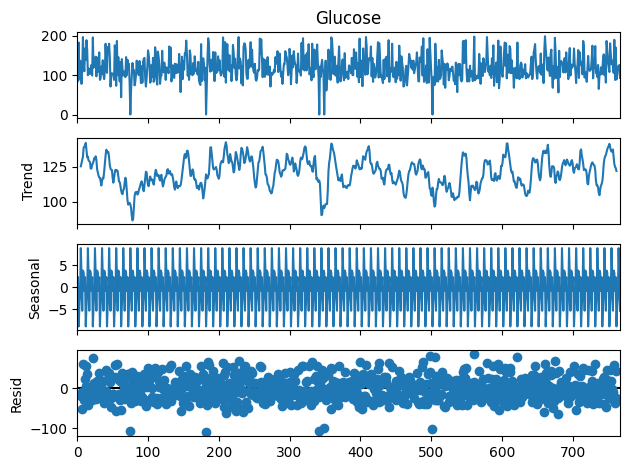

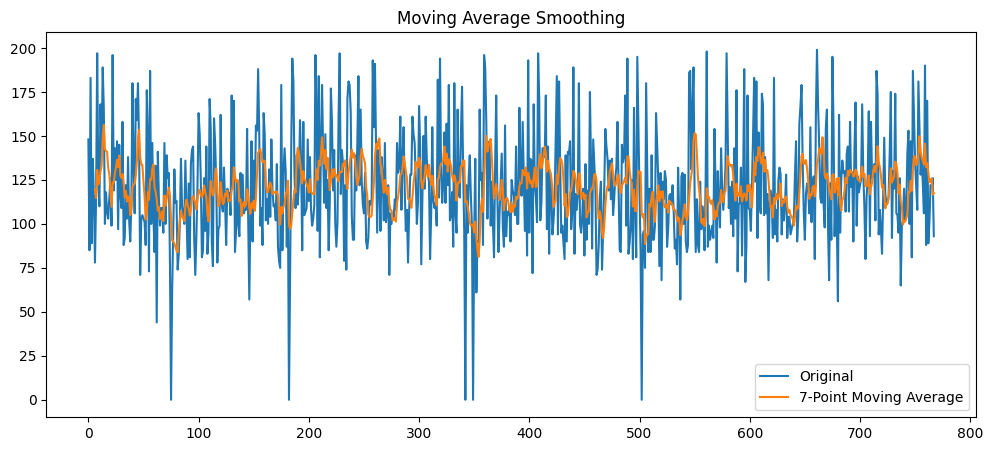

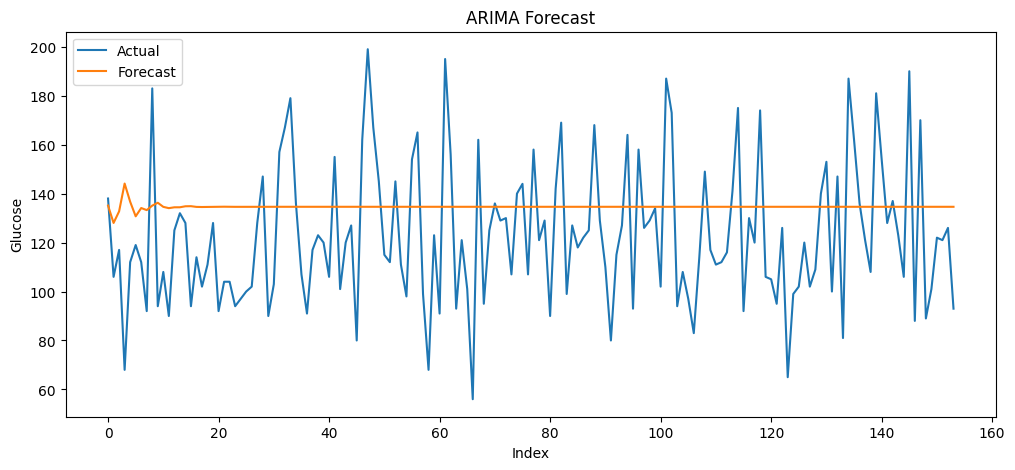

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Load Dataset
diabetes_data = pd.read_csv("uci_diabetes.csv")

# Display first 5 rows
print(diabetes_data.head())

# Plot Time Series Data
plt.figure(figsize=(12, 5))
plt.plot(diabetes_data["Glucose"], label="Glucose Level")
plt.xlabel("Index")
plt.ylabel("Glucose")
plt.title("Time Series of Glucose Levels")
plt.legend()
plt.show()

# Time Series Decomposition
decomposition = seasonal_decompose(
    diabetes_data["Glucose"],
    model="additive",
    period=10
)

decomposition.plot()
plt.show()

# Moving Average
diabetes_data["Glucose_MA"] = (
    diabetes_data["Glucose"].rolling(window=7).mean()
)

plt.figure(figsize=(12, 5))
plt.plot(diabetes_data["Glucose"], label="Original")
plt.plot(diabetes_data["Glucose_MA"], label="7-Point Moving Average")
plt.legend()
plt.title("Moving Average Smoothing")
plt.show()

# Train-Test Split
train_size = int(len(diabetes_data) * 0.8)

train = diabetes_data["Glucose"][:train_size]
test = diabetes_data["Glucose"][train_size:]

# ARIMA Model
model = ARIMA(train, order=(5, 1, 0))
fitted_model = model.fit()

# Forecast
forecast = fitted_model.forecast(steps=len(test))

# Plot Forecast
plt.figure(figsize=(12, 5))
plt.plot(test.values, label="Actual")
plt.plot(forecast.values, label="Forecast")
plt.xlabel("Index")
plt.ylabel("Glucose")
plt.title("ARIMA Forecast")
plt.legend()
plt.show()